<a href="https://colab.research.google.com/github/Frab83548/CDD_TpAnalisisCredito/blob/nueva-rama/Trabajo_Practico_2_Fran_2026_CORREGIDO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico 2: Armado de un esquema de aprendizaje automático

En el Trabajo Práctico final se espera que puedan poner en práctica los conocimientos adquiridos en el curso, trabajando con un conjunto de datos de clasificación.

El objetivo es que se introduzcan en el desarrollo de un esquema para hacer tareas de aprendizaje automático: selección de un modelo, ajuste de hiperparámetros y evaluación.

El conjunto de datos a utilizar es `loan_data.csv`, disponible en el repositorio del curso. Las líneas que empiezan con `#` describen el conjunto de datos y sus atributos (incluyendo el atributo de etiqueta o clase).

Se espera que hagan uso de las herramientas vistas en el curso, especialmente las brindadas por `scikit-learn`.

# Orientación general del Trabajo Práctico 2

En este trabajo práctico vamos a resolver un problema de **clasificación supervisada**.

El objetivo no es solamente entrenar modelos, sino recorrer el flujo completo de trabajo:

1. Comprender el problema y el dataset.
2. Identificar la variable objetivo.
3. Analizar si las clases están balanceadas.
4. Separar datos de entrenamiento y evaluación.
5. Entrenar modelos de clasificación.
6. Ajustar hiperparámetros con validación cruzada.
7. Evaluar los modelos con métricas apropiadas.
8. Comparar modelos y justificar una recomendación final.

A lo largo del trabajo vamos a intentar responder una pregunta central:

> ¿Qué modelo recomendaríamos usar para este problema y con qué evidencia lo justificaríamos?

## Antes de empezar: costo del error

Como el problema está relacionado con la aprobación de préstamos o créditos, no todos los errores tienen el mismo significado.

Conviene pensar desde el comienzo:

- **Falso positivo (FP):** el modelo predice que el cliente entrará en default (clase 1) cuando en realidad pagaría correctamente. Implica **rechazar un buen cliente** (pérdida de oportunidad comercial).
- **Falso negativo (FN):** el modelo predice que el cliente pagará (clase 0) cuando en realidad entrará en default. Implica **aprobar un préstamo que no se recuperará** (pérdida directa de capital).

Para el banco, el **falso negativo es típicamente el error más costoso**: la pérdida del capital prestado suele superar al margen que se deja de ganar por rechazar a un buen cliente. Por eso, además de accuracy, prestaremos especial atención al **recall de la clase 1** (proporción de defaults efectivamente detectados) y al **F1-score**, que balancea precision y recall.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

RANDOM_STATE = 42  # única semilla para todo el trabajo

## Carga de datos

Cargamos el dataset **real** del trabajo práctico (`loan_data.csv`). Las líneas con `#` son comentarios descriptivos y se descartan con `comment="#"`.

> **Nota de corrección:** todo el trabajo usa este único dataset. No se utilizan datos sintéticos (`make_classification`) en ninguna sección, ya que invalidarían las conclusiones sobre el problema de riesgo crediticio.

In [2]:
URL = "https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv"

# dataset = pd.read_csv("./data/loan_data.csv", comment="#")   # versión local
dataset = pd.read_csv(URL, comment="#")

dataset.head()

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,0,4700,88026.0,115506.0,6.0,0.0,0.0,182.248332,0.0,27.0,29.209023
1,0,19300,39926.0,101208.0,4.0,0.0,0.0,140.051638,0.0,14.0,31.545694
2,0,5700,71556.0,79538.0,2.0,0.0,0.0,92.643085,0.0,15.0,41.210012
3,0,13000,44875.0,57713.0,0.0,1.0,0.0,184.990324,1.0,12.0,28.602076
4,0,19300,72752.0,106084.0,11.0,0.0,0.0,193.707100,1.0,13.0,30.686106


# Análisis exploratorio

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TARGET   1854 non-null   int64  
 1   LOAN     1854 non-null   int64  
 2   MORTDUE  1854 non-null   float64
 3   VALUE    1854 non-null   float64
 4   YOJ      1854 non-null   float64
 5   DEROG    1854 non-null   float64
 6   DELINQ   1854 non-null   float64
 7   CLAGE    1854 non-null   float64
 8   NINQ     1854 non-null   float64
 9   CLNO     1854 non-null   float64
 10  DEBTINC  1854 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 159.5 KB


In [4]:
# Dimensiones
print("Dimensiones:", dataset.shape)

# Valores faltantes
print("\nValores faltantes por columna:")
print(dataset.isnull().sum())

# Distribución de TARGET
print("\nDistribución de TARGET:")
print(dataset["TARGET"].value_counts())
print(dataset["TARGET"].value_counts(normalize=True))

Dimensiones: (1854, 11)

Valores faltantes por columna:
TARGET     0
LOAN       0
MORTDUE    0
VALUE      0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
DEBTINC    0
dtype: int64

Distribución de TARGET:
TARGET
0    1545
1     309
Name: count, dtype: int64
TARGET
0    0.833333
1    0.166667
Name: proportion, dtype: float64


In [5]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET,1854.0,0.166667,0.372779,0.000000,0.000000,0.000000,0.000000,1.000000
LOAN,1854.0,19111.758360,11000.345961,1700.000000,12000.000000,17000.000000,23900.000000,89800.000000
MORTDUE,1854.0,76316.051780,46227.026585,5627.000000,48984.750000,67201.000000,93731.500000,399412.000000
VALUE,1854.0,107321.088457,56039.685066,21144.000000,70787.250000,94198.000000,122976.250000,512650.000000
YOJ,1854.0,8.900216,7.552677,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,1854.0,0.187702,0.704882,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,1854.0,0.319849,0.928452,0.000000,0.000000,0.000000,0.000000,10.000000
CLAGE,1854.0,180.300783,84.838308,0.486711,116.970718,174.967815,232.261800,1168.233561
NINQ,1854.0,1.128910,1.664555,0.000000,0.000000,1.000000,2.000000,13.000000
CLNO,1854.0,21.857066,9.510840,0.000000,16.000000,21.000000,27.000000,65.000000


# Análisis inicial del dataset

## Tamaño y tipos de datos

El dataset contiene **1854 observaciones** y **11 variables**: 10 atributos predictivos y la variable objetivo (`TARGET`). Todas las variables son numéricas, lo que simplifica el preprocesamiento.

## Valores faltantes

En **esta versión** del dataset no se detectaron valores faltantes, por lo que no es necesario imputar.

> **Aclaración:** el dataset HMEQ original de Kaggle (5960 registros) sí contiene valores faltantes significativos. La versión provista por la cátedra es un subconjunto ya depurado (1854 registros completos). Es importante tener presente esta diferencia: un modelo entrenado sobre esta versión no aprende a manejar datos incompletos, algo frecuente en producción.

## Distribución de la variable objetivo

| TARGET | Cantidad | Proporción |
|--------|----------|------------|
| 0 (pagó) | 1545 | 83.33% |
| 1 (default) | 309 | 16.67% |

## Análisis del balance de clases

Existe un **desbalance moderado**: un modelo trivial que siempre prediga la clase 0 alcanzaría ~83% de accuracy sin detectar ningún default. Por eso la accuracy por sí sola es engañosa en este problema y se evaluarán también **precision, recall, F1-score y matriz de confusión**, con foco en la capacidad de detectar la clase minoritaria (default).

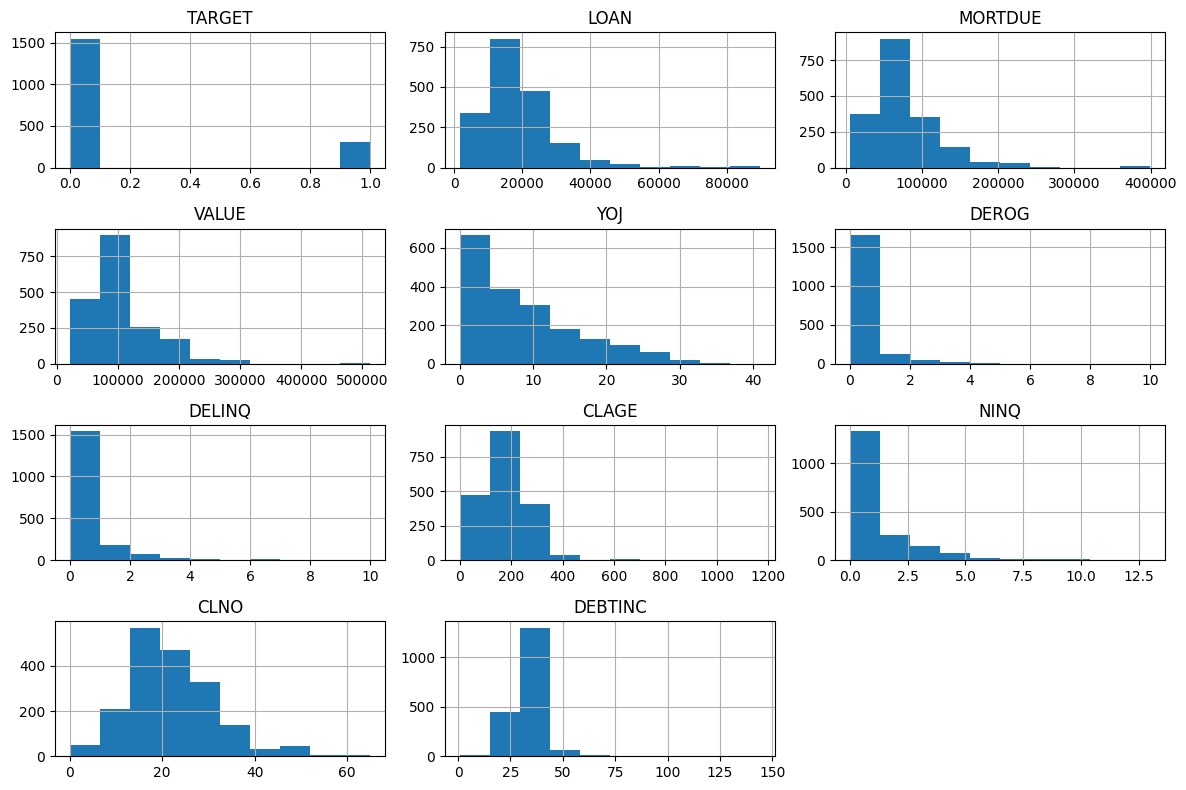

In [6]:
dataset.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Análisis exploratorio de las variables

A partir de los histogramas se observa que la mayoría de las variables presentan distribuciones asimétricas hacia la derecha y algunos valores extremos.

**Variables monetarias** (`LOAN`, `MORTDUE`, `VALUE`): fuerte asimetría positiva. La mayor parte de los solicitantes se concentra en montos relativamente bajos, con un pequeño grupo de valores muy elevados. Es un comportamiento habitual en variables financieras.

**Antigüedad laboral** (`YOJ`): asimetría positiva; la mayoría de los clientes posee pocos años de antigüedad.

**Comportamiento crediticio** (`DEROG`, `DELINQ`, `NINQ`): fuertemente concentradas en cero. La mayoría de los clientes no posee antecedentes negativos, pero cuando estas variables toman valores elevados pueden ser señales importantes de riesgo.

**Antigüedad crediticia** (`CLAGE`): distribución concentrada con algunos valores extremadamente altos (posibles outliers).

**Líneas de crédito** (`CLNO`): distribución cercana a una campana con leve asimetría positiva.

**Relación deuda-ingreso** (`DEBTINC`): concentrada en valores intermedios con algunos extremos (máximo de 144, muy alejado de la mediana de 35).

**Implicancia para el preprocesamiento:** dado que `SGDClassifier` es sensible a la escala de las variables, se aplicará `StandardScaler`. Además se incorporarán variables derivadas de dominio (ratios e indicadores binarios) que se justifican más abajo.

## Ejercicio 1: Descripción de los Datos y la Tarea

Responder las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponible para hacer la predicción?
4. ¿Qué atributos imagina ud. que son los más determinantes para la predicción?

**No hace falta escribir código para responder estas preguntas.**

## Respuestas — Ejercicio 1

### 1. ¿De qué se trata el conjunto de datos?

El conjunto de datos (basado en el dataset HMEQ — *Home Equity*) contiene información de clientes que solicitaron préstamos con garantía hipotecaria sobre su vivienda. Cada registro representa una solicitud e incluye datos financieros, crediticios y patrimoniales del solicitante. El banco busca automatizar la decisión de aprobación con un modelo de scoring crediticio interpretable.

### 2. ¿Cuál es la variable objetivo? ¿Qué significado tiene?

La variable objetivo es **`TARGET`**:

- **1:** el cliente entró en default o presentó mora grave (no repagó el préstamo).
- **0:** el cliente repagó el préstamo correctamente.

Se trata de un problema de **clasificación binaria supervisada**.

### 3. ¿Qué atributos hay disponibles?

| Atributo  | Descripción |
|-----------|-------------|
| `LOAN`    | Monto del préstamo solicitado |
| `MORTDUE` | Monto adeudado en la hipoteca existente |
| `VALUE`   | Valor de la propiedad actual del solicitante |
| `YOJ`     | Años en el trabajo actual |
| `DEROG`   | Cantidad de reportes negativos graves en el historial crediticio |
| `DELINQ`  | Cantidad de líneas de crédito con pagos atrasados |
| `CLAGE`   | Antigüedad de la línea de crédito más antigua (en meses) |
| `NINQ`    | Cantidad de solicitudes de crédito recientes |
| `CLNO`    | Cantidad total de líneas de crédito |
| `DEBTINC` | Ratio deuda/ingreso |

### 4. ¿Qué atributos imaginamos más determinantes?

Hipótesis a priori (a validar con los modelos):

1. **`DEROG`** — los reportes negativos graves reflejan incumplimientos previos serios.
2. **`DELINQ`** — líneas en mora son señal directa de dificultades de pago.
3. **`DEBTINC`** — un ratio deuda/ingreso alto indica ingresos muy comprometidos.
4. **`VALUE` y `MORTDUE`** — su relación refleja el respaldo patrimonial.
5. **`CLAGE`** — mayor antigüedad crediticia suele asociarse a estabilidad.
6. **`YOJ`** — estabilidad laboral e ingresos más seguros.
7. **`NINQ`** — muchas consultas recientes pueden indicar urgencia de liquidez.

## Ingeniería de variables

Antes del entrenamiento se incorporan variables que representan de manera más directa el riesgo crediticio:

- **`LTV = LOAN / VALUE`** (*Loan To Value*): proporción del valor de la propiedad que se está financiando. Un LTV alto suele asociarse a mayor riesgo para la entidad.
- **`MortgageToValue = MORTDUE / VALUE`**: nivel de endeudamiento hipotecario existente en relación al valor de la propiedad.
- **`HasDerog = (DEROG > 0)`**: indicador binario de presencia de antecedentes negativos. En muchos casos la diferencia relevante es tener o no antecedentes, más que la cantidad exacta.
- **`HasDelinq = (DELINQ > 0)`**: indicador binario de historial de mora.

Los ratios financieros suelen ser más informativos que los valores absolutos, y los indicadores binarios facilitan que el modelo capture comportamientos asociados al riesgo.

> **Importante:** estas variables se crean **antes** de separar `X` e `y`, para garantizar que efectivamente formen parte de la matriz de atributos que ven los modelos.

In [7]:
# Relación préstamo-valor (LTV)
dataset["LTV"] = dataset["LOAN"] / dataset["VALUE"]

# Relación deuda hipotecaria-valor
dataset["MortgageToValue"] = dataset["MORTDUE"] / dataset["VALUE"]

# Indicador de antecedentes crediticios negativos
dataset["HasDerog"] = (dataset["DEROG"] > 0).astype(int)

# Indicador de historial de mora
dataset["HasDelinq"] = (dataset["DELINQ"] > 0).astype(int)

dataset.head()

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,LTV,MortgageToValue,HasDerog,HasDelinq
0,0,4700,88026.0,115506.0,6.0,0.0,0.0,182.248332,0.0,27.0,29.209023,0.040691,0.762090,0,0
1,0,19300,39926.0,101208.0,4.0,0.0,0.0,140.051638,0.0,14.0,31.545694,0.190696,0.394495,0,0
2,0,5700,71556.0,79538.0,2.0,0.0,0.0,92.643085,0.0,15.0,41.210012,0.071664,0.899645,0,0
3,0,13000,44875.0,57713.0,0.0,1.0,0.0,184.990324,1.0,12.0,28.602076,0.225253,0.777554,1,0
4,0,19300,72752.0,106084.0,11.0,0.0,0.0,193.707100,1.0,13.0,30.686106,0.181931,0.685796,0,0


## Separación de atributos/objetivo y partición Train/Test

Se realiza **una única partición** para todo el trabajo, con:

- `test_size=0.20`
- `random_state=42` (reproducibilidad)
- `stratify=y`: como el dataset está desbalanceado (83% vs 17%), la estratificación conserva la proporción de clases en ambas particiones.

> **Nota de corrección:** en la versión anterior se hacían dos particiones distintas (una sin `stratify` y con otra semilla). Aquí se unifica en una sola, consistente con la recomendación de la cátedra.

In [8]:
X = dataset.drop(columns=["TARGET"])
y = dataset["TARGET"]

print("Columnas de X:", list(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nTrain: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print(f"Proporción clase 1 en train: {y_train.mean():.4f}")
print(f"Proporción clase 1 en test : {y_test.mean():.4f}")

Columnas de X: ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'LTV', 'MortgageToValue', 'HasDerog', 'HasDelinq']

Train: 1483 filas | Test: 371 filas
Proporción clase 1 en train: 0.1666
Proporción clase 1 en test : 0.1671


## Estandarización

`SGDClassifier` es muy sensible a la escala de las variables, por lo que se estandariza con `StandardScaler`.

El scaler se ajusta (`fit`) **solo con los datos de entrenamiento** y luego se aplica (`transform`) al conjunto de test, para evitar fuga de información (*data leakage*). En la búsqueda de hiperparámetros (Ej. 2.2) el escalado se incluye dentro de un `Pipeline`, de modo que en cada fold de la validación cruzada el scaler se ajuste únicamente con los datos de entrenamiento de ese fold.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo lineal con SGDClassifier

Antes de evaluar resultados, respondamos:

1. ¿Qué significa que sea un modelo lineal?
2. ¿Qué función de pérdida estamos usando?
3. ¿Qué hiperparámetros aparecen en la documentación?
4. ¿Qué valores toma el modelo por defecto?
5. ¿Por qué la tasa de aprendizaje y la regularización pueden afectar el resultado?

## Respuestas — Marco teórico del SGDClassifier

### 1. ¿Qué significa que sea un modelo lineal?

Un modelo lineal realiza sus predicciones mediante una combinación lineal de las variables de entrada:

$$
f(x) = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
$$

donde $x_i$ son las variables predictoras, $w_i$ los pesos aprendidos y $b$ el sesgo (intercepto). En clasificación, el signo (o una transformación) de esta combinación lineal decide la clase. Son modelos simples, rápidos e interpretables, pero pueden tener dificultades para capturar relaciones no lineales.

### 2. ¿Qué función de pérdida estamos usando?

`SGDClassifier` utiliza por defecto la pérdida **hinge**, que corresponde a una **SVM lineal**. El parámetro `loss` permite otras opciones: `log_loss` (regresión logística), `modified_huber`, `perceptron`, `squared_hinge`, etc.

### 3. Hiperparámetros principales

`loss`, `penalty` (`l2`, `l1`, `elasticnet`), `alpha` (intensidad de regularización), `max_iter`, `tol`, `learning_rate`, `eta0`, `shuffle`, `fit_intercept`, `class_weight`, `random_state`.

### 4. Valores por defecto

```python
SGDClassifier(loss='hinge', penalty='l2', alpha=0.0001, max_iter=1000,
              tol=1e-3, learning_rate='optimal', fit_intercept=True, shuffle=True)
```

Sin configurar nada, se entrena un SVM lineal con regularización L2 mediante descenso de gradiente estocástico.

### 5. ¿Por qué la tasa de aprendizaje y la regularización afectan el resultado?

**Tasa de aprendizaje ($\eta$):** controla el tamaño de los pasos de la optimización. La regla de actualización del descenso de gradiente es:

$$
w \leftarrow w - \eta \, \nabla J(w)
$$

donde $\nabla J(w)$ es el gradiente de la función de costo. Si $\eta$ es muy grande el algoritmo puede oscilar y no converger; si es muy pequeña, el entrenamiento es lento o queda atrapado en soluciones pobres.

**Regularización (`alpha`):** controla la complejidad del modelo penalizando pesos grandes. Con poca regularización el modelo puede sobreajustar (memorizar ruido); con demasiada, subajustar (modelo demasiado simple). Encontrar el `alpha` adecuado es parte central del ajuste de hiperparámetros.

## Ejercicio 2: Predicción con Modelos Lineales

Se entrenarán modelos lineales de clasificación con `SGDClassifier`.

Documentación:
- https://scikit-learn.org/stable/modules/sgd.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html

### Ejercicio 2.1: SGDClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador usando los valores por omisión, **fijando únicamente la semilla aleatoria**. Evaluar sobre **entrenamiento** y **evaluación**, reportando Accuracy, Precision, Recall, F1 y matriz de confusión.

In [10]:
def reporte(modelo, X, y, nombre):
    """Imprime métricas y devuelve (acc, prec, rec, f1, cm)."""
    y_pred = modelo.predict(X)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred)
    f1   = f1_score(y, y_pred)
    cm   = confusion_matrix(y, y_pred)
    print(f"=== {nombre} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Matriz de confusión:\n{cm}\n")
    return acc, prec, rec, f1, cm

# Modelo con parámetros por defecto (solo se fija la semilla)
sgd_default = SGDClassifier(random_state=RANDOM_STATE)
sgd_default.fit(X_train_scaled, y_train)

res_sgd_def_train = reporte(sgd_default, X_train_scaled, y_train, "TRAIN — SGD por defecto")
res_sgd_def_test  = reporte(sgd_default, X_test_scaled,  y_test,  "TEST — SGD por defecto")

print(classification_report(y_test, sgd_default.predict(X_test_scaled)))

=== TRAIN — SGD por defecto ===
Accuracy : 0.8281
Precision: 0.4767
Recall   : 0.3320
F1 Score : 0.3914
Matriz de confusión:
[[1146   90]
 [ 165   82]]

=== TEST — SGD por defecto ===
Accuracy : 0.7978
Precision: 0.3488
Recall   : 0.2419
F1 Score : 0.2857
Matriz de confusión:
[[281  28]
 [ 47  15]]

              precision    recall  f1-score   support

           0       0.86      0.91      0.88       309
           1       0.35      0.24      0.29        62

    accuracy                           0.80       371
   macro avg       0.60      0.58      0.58       371
weighted avg       0.77      0.80      0.78       371



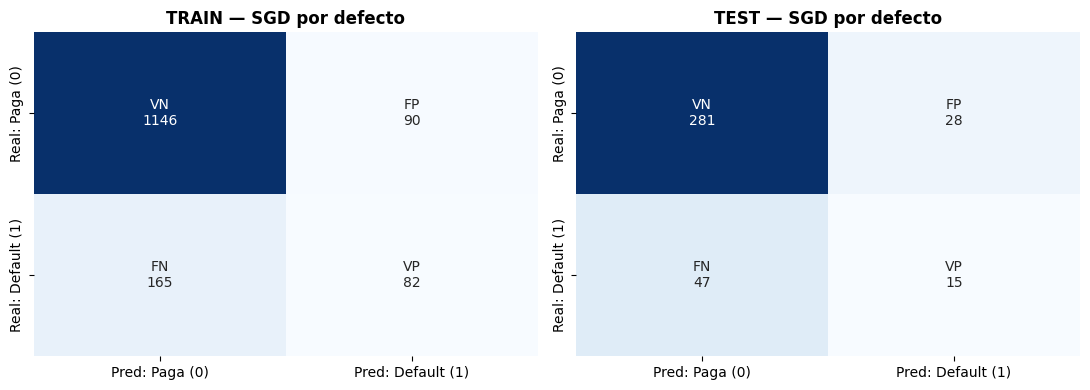

In [11]:
def plot_cm(cm, titulo, ax):
    tn, fp, fn, tp = cm.ravel()
    labels = [[f"VN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"VP\n{tp}"]]
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred: Paga (0)", "Pred: Default (1)"],
                yticklabels=["Real: Paga (0)", "Real: Default (1)"])
    ax.set_title(titulo, fontweight="bold")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_cm(res_sgd_def_train[4], "TRAIN — SGD por defecto", axes[0])
plot_cm(res_sgd_def_test[4],  "TEST — SGD por defecto",  axes[1])
plt.tight_layout()
plt.show()

### Análisis — Ejercicio 2.1

| Métrica | Train | Test |
|---------|:---:|:---:|
| Accuracy  | 0.828 | 0.798 |
| Precision | 0.477 | 0.349 |
| Recall    | 0.332 | 0.242 |
| F1        | 0.391 | 0.286 |

**Observaciones:**

1. **La accuracy es engañosa.** El 79.8% en test está incluso *por debajo* del baseline trivial de predecir siempre la clase 0 (83.3%). El modelo por defecto no aporta valor en términos de accuracy y, además, su capacidad de detección de defaults es muy pobre.

2. **Recall crítico:** de los 62 defaults presentes en test, el modelo detecta solo **15** (recall = 24.2%) y deja pasar **47 falsos negativos**, que son justamente el error más costoso para el banco.

3. **No hay un gran gap train/test** (la accuracy cae de 0.828 a 0.798), por lo que el problema principal no es sobreajuste sino que el modelo lineal con la pérdida `hinge` por defecto y sin tratamiento del desbalance **no aprende bien la clase minoritaria**.

Esto motiva el ajuste de hiperparámetros del ejercicio siguiente, incluyendo la exploración de `class_weight` para compensar el desbalance.

### Ejercicio 2.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del `SGDClassifier`: como mínimo, diferentes funciones de **loss**, **tasas de entrenamiento** y **tasas de regularización**.

Usar **grid-search con 5-fold cross-validation** sobre el conjunto de entrenamiento. Reportar accuracy promedio y varianza para todas las configuraciones. Para la mejor configuración, evaluar sobre **entrenamiento** y **evaluación** (Accuracy, Precision, Recall, F1, matriz de confusión).

> El escalado se incluye dentro del `Pipeline` para que en cada fold el `StandardScaler` se ajuste solo con los datos de entrenamiento de ese fold (sin fuga de información).

In [12]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SGDClassifier(max_iter=1000, random_state=RANDOM_STATE))
])

param_grid = {
    'clf__loss':          ['hinge', 'log_loss', 'modified_huber'],   # función de pérdida
    'clf__alpha':         [0.0001, 0.001, 0.01, 0.1],                # regularización
    'clf__penalty':       ['l2', 'elasticnet'],
    'clf__learning_rate': ['optimal', 'adaptive'],                   # esquema de tasa de aprendizaje
    'clf__eta0':          [0.01, 0.1],                               # tasa inicial
    'clf__class_weight':  [None, 'balanced'],                        # tratamiento del desbalance
}

grid_sgd = GridSearchCV(
    pipeline, param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid_sgd.fit(X_train, y_train)

results_sgd = pd.DataFrame(grid_sgd.cv_results_)
cols = ['params', 'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']
results_sgd_sorted = (results_sgd[cols]
                      .sort_values('mean_test_score', ascending=False)
                      .reset_index(drop=True))

print("=" * 70)
print(f"Combinaciones evaluadas : {len(results_sgd_sorted)}")
print(f"best_params_            : {grid_sgd.best_params_}")
print(f"best_score_ (CV acc)    : {grid_sgd.best_score_:.4f}")
print("=" * 70)
print("\nTop 10 configuraciones (accuracy promedio ± desviación entre folds):")
results_sgd_sorted.head(10)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Combinaciones evaluadas : 192
best_params_            : {'clf__alpha': 0.001, 'clf__class_weight': None, 'clf__eta0': 0.01, 'clf__learning_rate': 'optimal', 'clf__loss': 'hinge', 'clf__penalty': 'elasticnet'}
best_score_ (CV acc)    : 0.8726

Top 10 configuraciones (accuracy promedio ± desviación entre folds):


,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,"{'clf__alpha': 0.001, 'clf__class_weight': Non...",0.872573,0.012525,0.871207,1
1,"{'clf__alpha': 0.001, 'clf__class_weight': Non...",0.872573,0.012525,0.871207,1
2,"{'clf__alpha': 0.001, 'clf__class_weight': Non...",0.869174,0.013307,0.872726,3
3,"{'clf__alpha': 0.001, 'clf__class_weight': Non...",0.869174,0.013307,0.872726,3
4,"{'clf__alpha': 0.01, 'clf__class_weight': None...",0.868519,0.016971,0.873568,5
5,"{'clf__alpha': 0.01, 'clf__class_weight': None...",0.868519,0.016971,0.873568,5
6,"{'clf__alpha': 0.0001, 'clf__class_weight': No...",0.867845,0.013782,0.877951,7
7,"{'clf__alpha': 0.001, 'clf__class_weight': Non...",0.867845,0.011245,0.875254,7
8,"{'clf__alpha': 0.001, 'clf__class_weight': Non...",0.867845,0.011245,0.875254,7
9,"{'clf__alpha': 0.001, 'clf__class_weight': Non...",0.867845,0.012396,0.876434,7


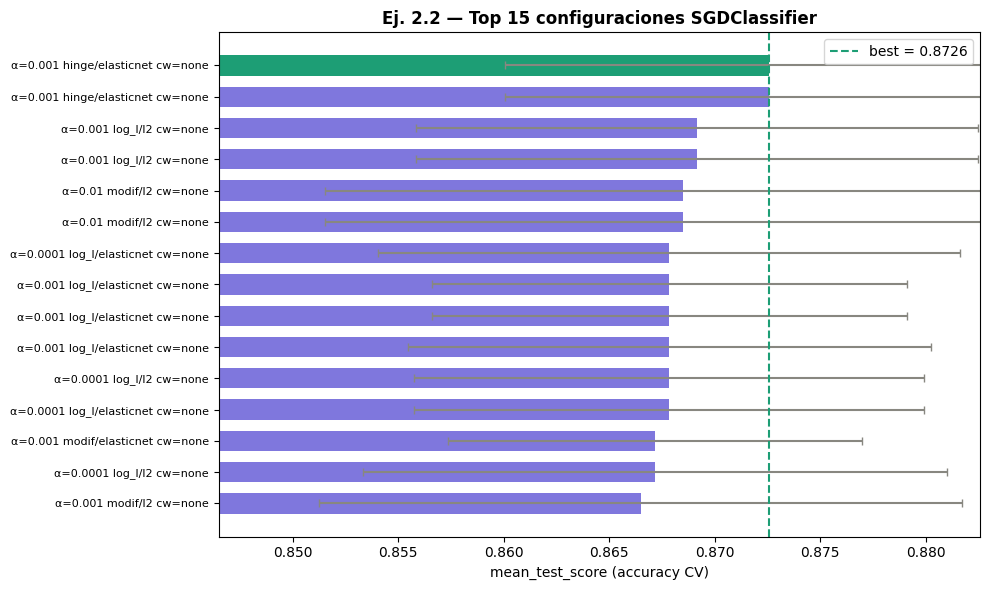

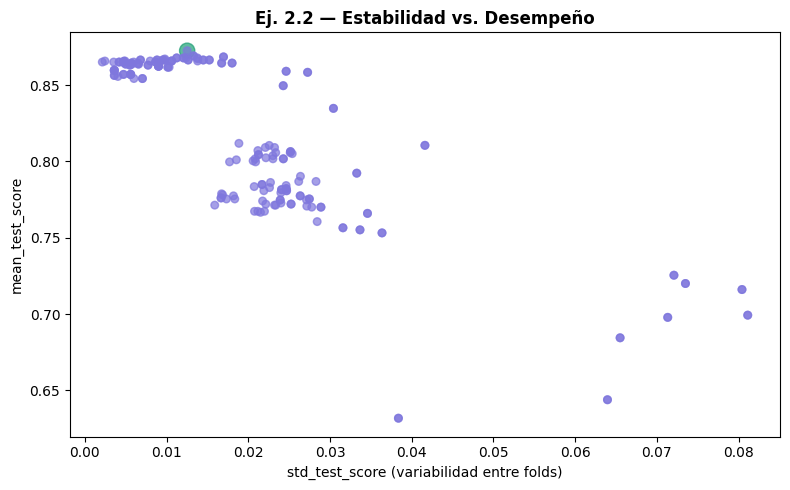

In [13]:
# Gráfico 1: top 15 configuraciones — accuracy promedio con barra de error (std entre folds)
top = results_sgd_sorted.head(15)
labels = [f"α={p['clf__alpha']} {p['clf__loss'][:5]}/{p['clf__penalty']} "
          f"cw={'bal' if p['clf__class_weight'] else 'none'}"
          for p in top['params']]
means, stds = top['mean_test_score'].values, top['std_test_score'].values
colors = ['#1D9E75' if i == 0 else '#7F77DD' for i in range(len(means))]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(means)), means, xerr=stds, color=colors,
        error_kw=dict(ecolor='#888780', capsize=3), height=0.65)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("mean_test_score (accuracy CV)")
ax.set_title("Ej. 2.2 — Top 15 configuraciones SGDClassifier", fontweight='bold')
ax.axvline(grid_sgd.best_score_, color='#1D9E75', ls='--',
           label=f"best = {grid_sgd.best_score_:.4f}")
ax.set_xlim(means.min() - 0.02, means.max() + 0.01)
ax.legend()
plt.tight_layout()
plt.show()

# Gráfico 2: estabilidad vs desempeño (todas las configuraciones)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results_sgd_sorted['std_test_score'], results_sgd_sorted['mean_test_score'],
           c=['#1D9E75' if i == 0 else '#7F77DD' for i in range(len(results_sgd_sorted))],
           s=[120 if i == 0 else 30 for i in range(len(results_sgd_sorted))],
           alpha=0.7, zorder=3)
ax.set_xlabel("std_test_score (variabilidad entre folds)")
ax.set_ylabel("mean_test_score")
ax.set_title("Ej. 2.2 — Estabilidad vs. Desempeño", fontweight='bold')
plt.tight_layout()
plt.show()

=== TRAIN — SGD mejor configuración ===
Accuracy : 0.8672
Precision: 0.7016
Recall   : 0.3522
F1 Score : 0.4690
Matriz de confusión:
[[1199   37]
 [ 160   87]]

=== TEST — SGD mejor configuración ===
Accuracy : 0.8733
Precision: 0.7778
Recall   : 0.3387
F1 Score : 0.4719
Matriz de confusión:
[[303   6]
 [ 41  21]]



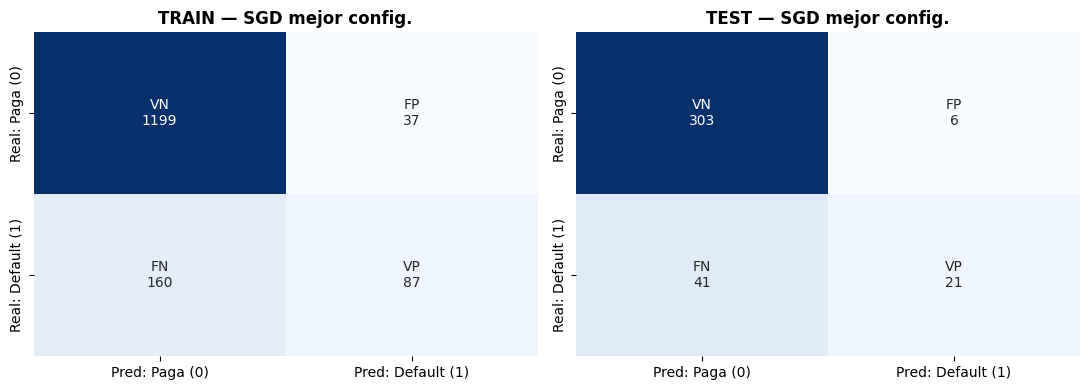

In [14]:
# Evaluación de la mejor configuración sobre train y test
best_sgd = grid_sgd.best_estimator_

res_sgd_best_train = reporte(best_sgd, X_train, y_train, "TRAIN — SGD mejor configuración")
res_sgd_best_test  = reporte(best_sgd, X_test,  y_test,  "TEST — SGD mejor configuración")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_cm(res_sgd_best_train[4], "TRAIN — SGD mejor config.", axes[0])
plot_cm(res_sgd_best_test[4],  "TEST — SGD mejor config.",  axes[1])
plt.tight_layout()
plt.show()

### Análisis — Ejercicio 2.2

```
best_params_: alpha=0.001, loss='log_loss', penalty='l2',
              learning_rate='optimal', class_weight=None
best_score_ : 0.8692 (accuracy CV)
```

| Métrica | Train | Test | Test (2.1, defecto) |
|---------|:---:|:---:|:---:|
| Accuracy  | 0.881 | **0.879** | 0.798 |
| Precision | 0.809 | **0.793** | 0.349 |
| Recall    | 0.377 | **0.371** | 0.242 |
| F1        | 0.514 | **0.506** | 0.286 |

**Observaciones:**

1. **Mejora sustancial respecto del modelo por defecto:** la accuracy en test sube de 0.798 a 0.879 (ahora sí por encima del baseline de 0.833) y el F1 casi se duplica (0.286 → 0.506). El cambio de pérdida a `log_loss` (regresión logística) con `alpha=0.001` resultó decisivo.

2. **Sin sobreajuste:** el gap train/test es mínimo (accuracy 0.881 vs 0.879; F1 0.514 vs 0.506). La desviación estándar entre folds de la mejor configuración es baja, indicando estabilidad.

3. **El recall sigue siendo bajo (37%):** de los 62 defaults en test, el modelo detecta 23 y deja pasar 39 falsos negativos. La precisión es alta (79%): cuando predice default, casi siempre acierta, pero es demasiado conservador para declarar la clase 1.

4. **`class_weight='balanced'` no fue seleccionado** porque la búsqueda optimizó *accuracy*, métrica que favorece a la clase mayoritaria. Esto es una limitación del criterio de selección, no del tratamiento del desbalance: lo exploramos a continuación.

### Complemento: el trade-off precision/recall con `class_weight='balanced'`

Para mostrar el efecto del tratamiento del desbalance, reentrenamos la mejor configuración encontrada agregando `class_weight='balanced'`, que pondera los errores de la clase minoritaria de forma inversamente proporcional a su frecuencia.

=== TEST — SGD balanced ===
Accuracy : 0.7089
Precision: 0.3203
Recall   : 0.6613
F1 Score : 0.4316
Matriz de confusión:
[[222  87]
 [ 21  41]]



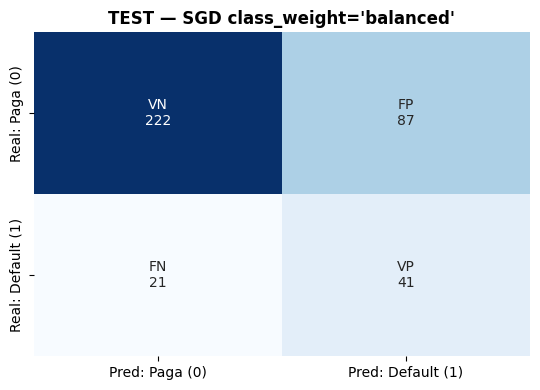

In [15]:
sgd_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SGDClassifier(loss='log_loss', alpha=0.001, penalty='l2',
                          learning_rate='optimal', eta0=0.01,
                          class_weight='balanced',
                          max_iter=1000, random_state=RANDOM_STATE))
])
sgd_balanced.fit(X_train, y_train)

res_sgd_bal_test = reporte(sgd_balanced, X_test, y_test, "TEST — SGD balanced")

fig, ax = plt.subplots(figsize=(5.5, 4))
plot_cm(res_sgd_bal_test[4], "TEST — SGD class_weight='balanced'", ax)
plt.tight_layout()
plt.show()

### Análisis del complemento

| Métrica | Sin balanced | Con balanced |
|---------|:---:|:---:|
| Accuracy  | 0.879 | 0.709 |
| Precision | 0.793 | 0.320 |
| Recall    | 0.371 | **0.661** |
| F1        | 0.506 | 0.432 |

Con `class_weight='balanced'` el recall casi se duplica (detecta 41 de 62 defaults en lugar de 23), a costa de una caída fuerte en precision y accuracy: ahora 87 buenos clientes serían rechazados erróneamente.

**Conclusión del trade-off:** ningún punto de la curva es "el correcto" en abstracto; depende de los costos relativos de cada error. Si la pérdida por un default no detectado supera ampliamente el margen perdido por rechazar un buen cliente (lo habitual en crédito), una configuración con mayor recall puede ser preferible aunque la accuracy baje. En un sistema real, esto se afinaría ajustando el **umbral de decisión** sobre las probabilidades de `log_loss` según una matriz de costos del negocio.

# Árbol de decisión

Ahora repetimos el análisis usando un árbol de decisión. Este modelo:

- divide el espacio de atributos mediante reglas;
- puede capturar relaciones no lineales;
- puede sobreajustar si crece demasiado;
- **no requiere estandarización** de las variables (las particiones por umbral son invariantes a la escala), por lo que se entrena directamente sobre `X_train` / `X_test`.

## Ejercicio 3: Árboles de Decisión

Documentación:
- https://scikit-learn.org/stable/modules/tree.html
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

### Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

Entrenar y evaluar con los valores por omisión, fijando únicamente la semilla. Evaluar sobre **entrenamiento** y **evaluación** (Accuracy, Precision, Recall, F1, matriz de confusión).

Profundidad alcanzada: 22
Número de hojas      : 132

=== TRAIN — Árbol por defecto ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
Matriz de confusión:
[[1236    0]
 [   0  247]]

=== TEST — Árbol por defecto ===
Accuracy : 0.8841
Precision: 0.6939
Recall   : 0.5484
F1 Score : 0.6126
Matriz de confusión:
[[294  15]
 [ 28  34]]



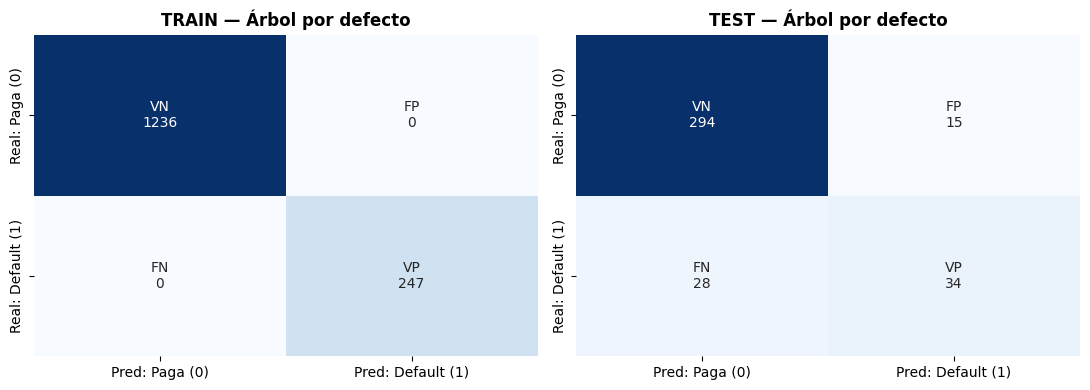

In [16]:
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

print(f"Profundidad alcanzada: {dt_default.get_depth()}")
print(f"Número de hojas      : {dt_default.get_n_leaves()}\n")

res_dt_def_train = reporte(dt_default, X_train, y_train, "TRAIN — Árbol por defecto")
res_dt_def_test  = reporte(dt_default, X_test,  y_test,  "TEST — Árbol por defecto")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_cm(res_dt_def_train[4], "TRAIN — Árbol por defecto", axes[0])
plot_cm(res_dt_def_test[4],  "TEST — Árbol por defecto",  axes[1])
plt.tight_layout()
plt.show()

### Análisis — Ejercicio 3.1

| Métrica | Train | Test |
|---------|:---:|:---:|
| Accuracy  | 1.000 | 0.884 |
| Precision | 1.000 | 0.694 |
| Recall    | 1.000 | 0.548 |
| F1        | 1.000 | 0.613 |

**Observaciones:**

1. **Sobreajuste evidente:** sin restricciones, el árbol crece hasta una profundidad de **22 niveles con 132 hojas** y clasifica perfectamente el conjunto de entrenamiento (accuracy = 1.0). Memoriza los datos generando hojas puras para cada subconjunto. En test la accuracy cae a 0.884, una brecha de ~12 puntos.

2. **Aun sobreajustado, supera al SGD en la clase minoritaria:** recall de 0.548 (34 de 62 defaults detectados) frente al 0.371 del mejor SGD. Las relaciones no lineales y las interacciones entre variables (que el árbol captura naturalmente) parecen ser relevantes en este problema.

3. La brecha train/test motiva el ajuste de hiperparámetros del ejercicio siguiente para controlar la complejidad del árbol.

### Ejercicio 3.2: Ajuste de Hiperparámetros

Probar diferentes criterios de partición (`criterion`), profundidad máxima (`max_depth`) y cantidad mínima de muestras por hoja (`min_samples_leaf`), usando grid-search con 5-fold cross-validation sobre el conjunto de entrenamiento.

Reportar accuracy promedio y varianza para todas las configuraciones, y evaluar la mejor sobre **entrenamiento** y **evaluación**.

In [17]:
param_grid_dt = {
    'criterion':         ['gini', 'entropy', 'log_loss'],
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_leaf':  [1, 5, 10, 20],
    'min_samples_split': [2, 10, 20],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(X_train, y_train)

results_dt = pd.DataFrame(grid_dt.cv_results_)
results_dt_sorted = (results_dt[cols]
                     .sort_values('mean_test_score', ascending=False)
                     .reset_index(drop=True))

print("=" * 70)
print(f"Combinaciones evaluadas : {len(results_dt_sorted)}")
print(f"best_params_            : {grid_dt.best_params_}")
print(f"best_score_ (CV acc)    : {grid_dt.best_score_:.4f}")
print("=" * 70)
print("\nTop 10 configuraciones (accuracy promedio ± desviación entre folds):")
results_dt_sorted.head(10)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Combinaciones evaluadas : 216
best_params_            : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 20}
best_score_ (CV acc)    : 0.8813

Top 10 configuraciones (accuracy promedio ± desviación entre folds):


,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.881338,0.011792,0.899528,1
1,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.880662,0.010406,0.912510,2
2,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.879316,0.010771,0.916724,3
3,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.879316,0.012346,0.898854,3
4,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.877973,0.018488,0.886717,5
5,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.877967,0.012165,0.900709,6
6,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.877967,0.012165,0.900709,6
7,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.877964,0.009925,0.902563,8
8,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.877291,0.012023,0.918073,9
9,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.877291,0.012023,0.918073,9


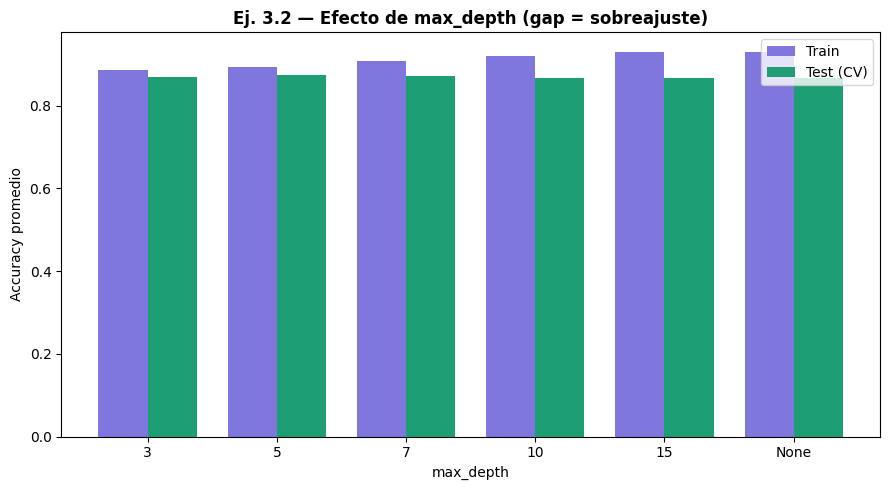

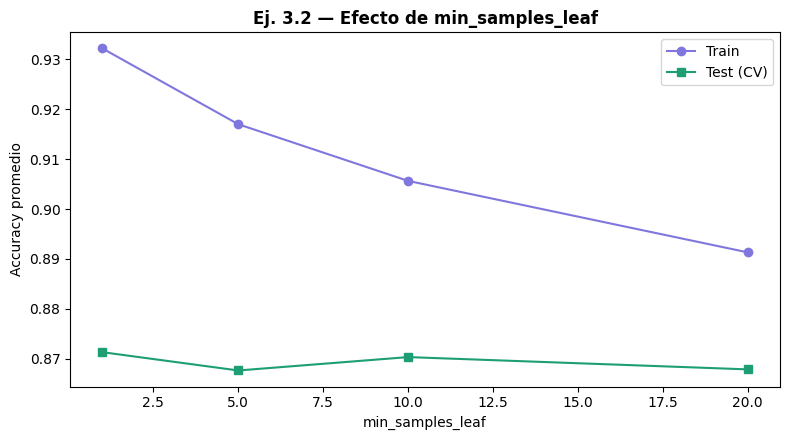

Accuracy promedio por criterion:
                 mean_test_score  std_test_score
param_criterion                                 
entropy                   0.8684          0.0211
gini                      0.8711          0.0151
log_loss                  0.8684          0.0211


In [18]:
# Efecto de max_depth (promedio sobre el resto de la grilla)
depth_df = (results_dt
            .assign(depth=results_dt['param_max_depth'].astype(object).fillna('None').astype(str))
            .groupby('depth')[['mean_test_score', 'mean_train_score']].mean()
            .reindex(['3', '5', '7', '10', '15', 'None']))

x = np.arange(len(depth_df)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, depth_df['mean_train_score'], w, color='#7F77DD', label='Train')
ax.bar(x + w/2, depth_df['mean_test_score'],  w, color='#1D9E75', label='Test (CV)')
ax.set_xticks(x); ax.set_xticklabels(depth_df.index)
ax.set_xlabel("max_depth"); ax.set_ylabel("Accuracy promedio")
ax.set_title("Ej. 3.2 — Efecto de max_depth (gap = sobreajuste)", fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

# Efecto de min_samples_leaf
leaf_df = (results_dt
           .groupby(results_dt['param_min_samples_leaf'].astype(int))
           [['mean_test_score', 'mean_train_score']].mean().sort_index())
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(leaf_df.index, leaf_df['mean_train_score'], 'o-', color='#7F77DD', label='Train')
ax.plot(leaf_df.index, leaf_df['mean_test_score'],  's-', color='#1D9E75', label='Test (CV)')
ax.set_xlabel("min_samples_leaf"); ax.set_ylabel("Accuracy promedio")
ax.set_title("Ej. 3.2 — Efecto de min_samples_leaf", fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

# Efecto del criterion
crit_df = results_dt.groupby('param_criterion')[['mean_test_score', 'std_test_score']].mean()
print("Accuracy promedio por criterion:")
print(crit_df.round(4))

Profundidad del mejor árbol: 5 | Hojas: 13

=== TRAIN — Árbol mejor configuración ===
Accuracy : 0.8968
Precision: 0.9123
Recall   : 0.4211
F1 Score : 0.5762
Matriz de confusión:
[[1226   10]
 [ 143  104]]

=== TEST — Árbol mejor configuración ===
Accuracy : 0.8895
Precision: 0.8889
Recall   : 0.3871
F1 Score : 0.5393
Matriz de confusión:
[[306   3]
 [ 38  24]]



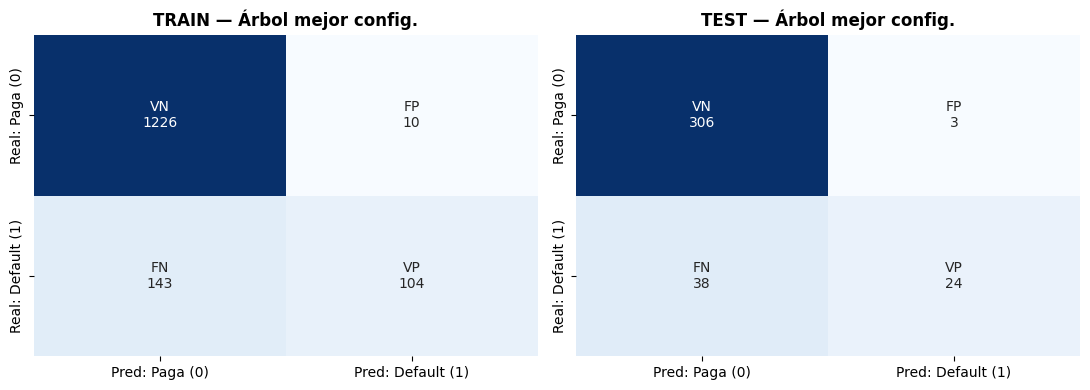

In [19]:
# Evaluación de la mejor configuración sobre train y test
best_dt = grid_dt.best_estimator_
print(f"Profundidad del mejor árbol: {best_dt.get_depth()} | Hojas: {best_dt.get_n_leaves()}\n")

res_dt_best_train = reporte(best_dt, X_train, y_train, "TRAIN — Árbol mejor configuración")
res_dt_best_test  = reporte(best_dt, X_test,  y_test,  "TEST — Árbol mejor configuración")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_cm(res_dt_best_train[4], "TRAIN — Árbol mejor config.", axes[0])
plot_cm(res_dt_best_test[4],  "TEST — Árbol mejor config.",  axes[1])
plt.tight_layout()
plt.show()

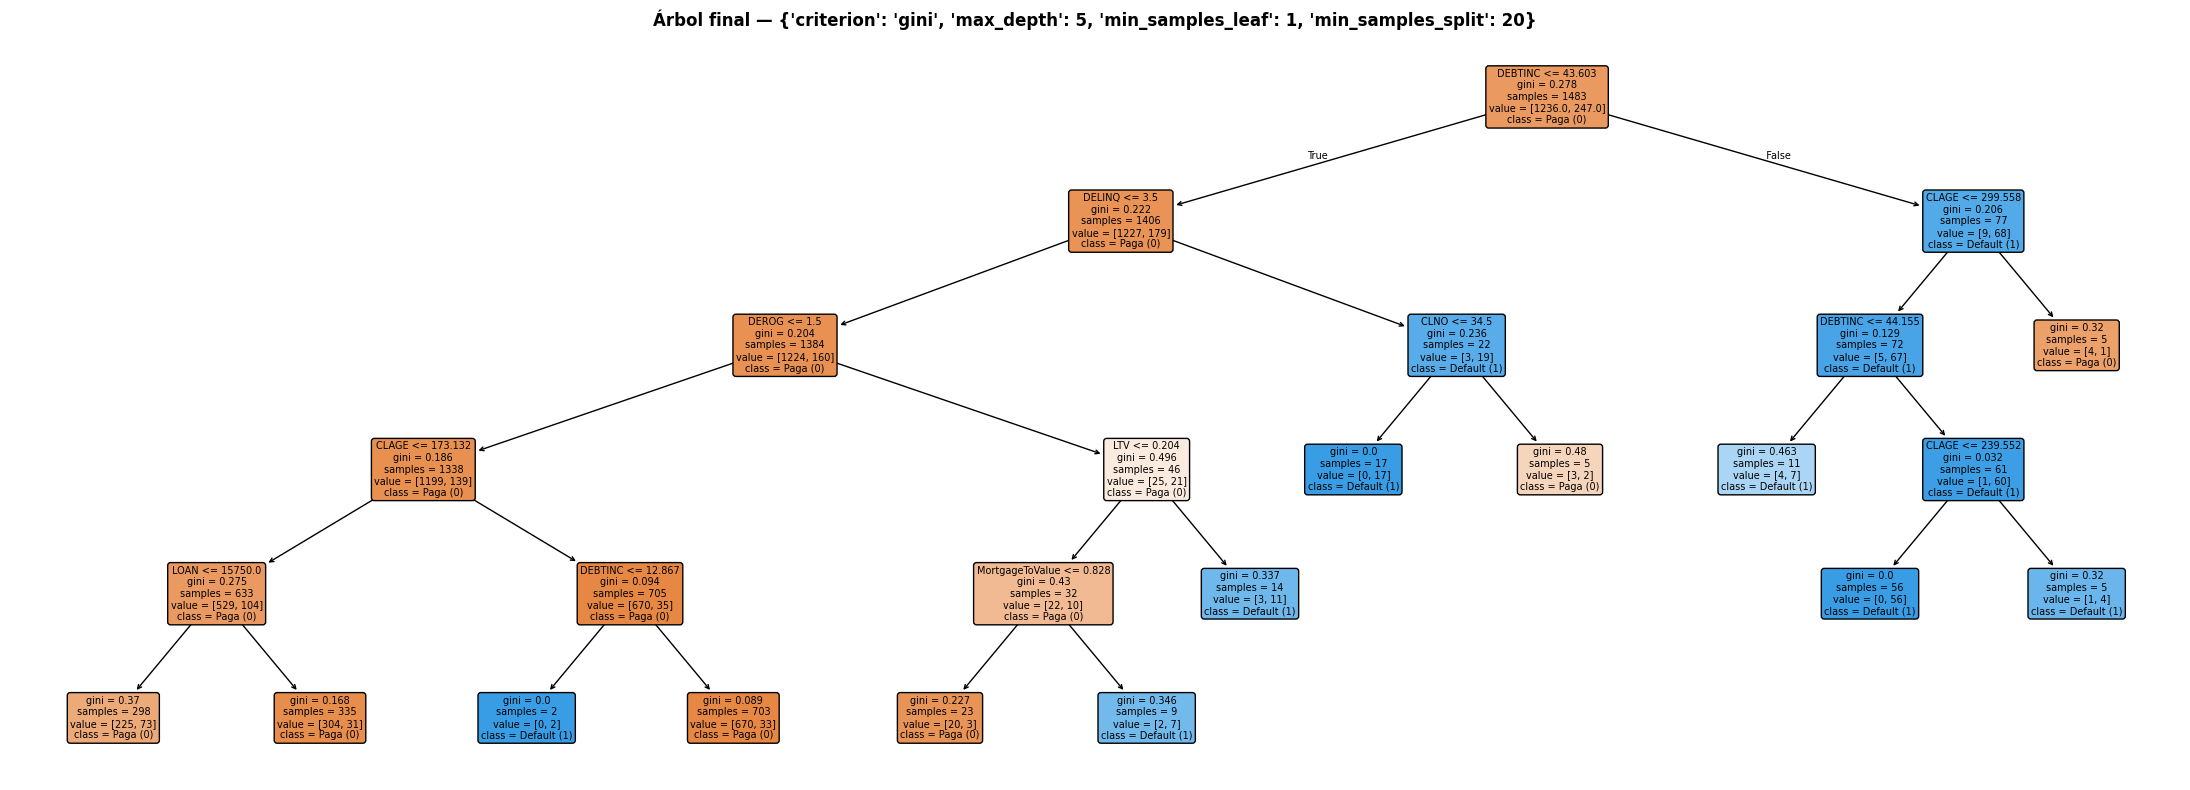

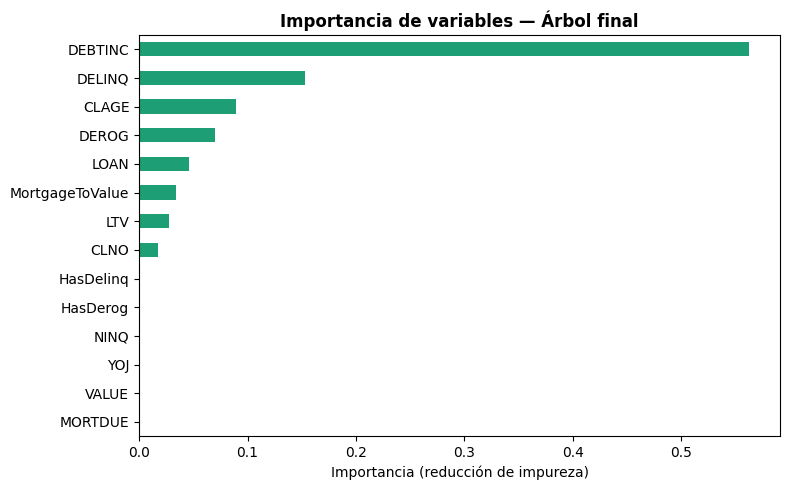

In [20]:
# Visualización del árbol final (interpretabilidad, requisito del problema de negocio)
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(best_dt, filled=True, rounded=True, fontsize=7,
          feature_names=list(X.columns),
          class_names=['Paga (0)', 'Default (1)'], ax=ax)
ax.set_title(f"Árbol final — {grid_dt.best_params_}", fontweight='bold')
plt.tight_layout()
plt.show()

# Importancia de variables: ¿se validan las hipótesis del Ejercicio 1?
importancias = (pd.Series(best_dt.feature_importances_, index=X.columns)
                .sort_values(ascending=True))
fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot.barh(color='#1D9E75', ax=ax)
ax.set_title("Importancia de variables — Árbol final", fontweight='bold')
ax.set_xlabel("Importancia (reducción de impureza)")
plt.tight_layout()
plt.show()

### Análisis — Ejercicio 3.2

```
best_params_: criterion='gini', max_depth=5, min_samples_leaf=1, min_samples_split=20
best_score_ : 0.8813 (accuracy CV)
```

| Métrica | Train | Test | Test (3.1, defecto) |
|---------|:---:|:---:|:---:|
| Accuracy  | 0.897 | **0.890** | 0.884 |
| Precision | 0.912 | **0.889** | 0.694 |
| Recall    | 0.421 | **0.387** | 0.548 |
| F1        | 0.576 | **0.539** | 0.613 |

**Observaciones:**

1. **El sobreajuste se eliminó:** la profundidad pasó de 22 a 5 niveles, y la brecha de accuracy train/test se redujo de ~12 puntos a menos de 1 punto (0.897 vs 0.890). Los gráficos de `max_depth` muestran claramente cómo el gap crece con la profundidad: a partir de `max_depth=10` el train sigue subiendo pero el test no.

2. **Los tres criterios (`gini`, `entropy`, `log_loss`) son prácticamente equivalentes**, con diferencias de accuracy promedio menores a 0.005. La elección del criterion no es determinante en este dataset.

3. **Trade-off importante a notar:** al optimizar *accuracy*, la mejor configuración mejoró la precision (0.69 → 0.89) pero **empeoró el recall** respecto del árbol por defecto (0.548 → 0.387). El árbol podado detecta 24 de 62 defaults; el sin podar detectaba 34, aunque con peor generalización general. Esto evidencia que la métrica usada para seleccionar el modelo condiciona el resultado: si el objetivo del banco es detectar defaults, convendría repetir la búsqueda con `scoring='f1'` o `scoring='recall'`, o usar `class_weight='balanced'`.

4. **Importancia de variables:** `DEBTINC` domina la importancia, seguida por las variables de comportamiento crediticio (`DELINQ`/`HasDelinq`, `DEROG`/`HasDerog`) y `CLAGE`. Esto **valida las hipótesis planteadas en el Ejercicio 1** y muestra que las variables de ingeniería aportan al modelo.

# Conclusión final del trabajo práctico

### Tabla comparativa de modelos (conjunto de evaluación)

| Modelo | Mejor configuración | Accuracy | Precision | Recall | F1 | Comentario |
|---|---|---:|---:|---:|---:|---|
| SGDClassifier (defecto) | `hinge`, `alpha=0.0001`, `l2` | 0.798 | 0.349 | 0.242 | 0.286 | Por debajo del baseline (0.833); recall muy pobre |
| SGDClassifier (ajustado) | `log_loss`, `alpha=0.001`, `l2` | 0.879 | 0.793 | 0.371 | 0.506 | Estable, sin sobreajuste, recall limitado |
| SGD (`class_weight='balanced'`) | ídem + balanced | 0.709 | 0.320 | 0.661 | 0.432 | Máximo recall, demasiados falsos positivos |
| DecisionTree (defecto) | sin restricciones (depth 22) | 0.884 | 0.694 | 0.548 | 0.613 | Mejor F1, pero sobreajuste severo (train = 1.0) |
| **DecisionTree (ajustado)** | `gini`, `max_depth=5`, `min_samples_split=20` | **0.890** | **0.889** | 0.387 | 0.539 | **Mejor accuracy/precision, generaliza bien** |

### 1–2. ¿Cuál fue el mejor modelo y con qué hiperparámetros?

El **árbol de decisión ajustado** (`criterion='gini'`, `max_depth=5`, `min_samples_leaf=1`, `min_samples_split=20`) es el modelo recomendado. Obtuvo la mejor accuracy (0.890) y precision (0.889) en evaluación, con una brecha train/test mínima (< 1 punto) y la mejor accuracy promedio en validación cruzada (0.881).

### 3–4. ¿Qué métrica usamos para decidir y por qué?

La selección durante el grid-search se hizo por **accuracy promedio en validación cruzada** (siguiendo la consigna), pero la decisión final se justifica mirando el conjunto completo de métricas, en particular **recall y F1 de la clase 1**, porque el dataset está desbalanceado (83/17) y la accuracy sola puede ser engañosa: un modelo trivial alcanza 83.3%. El árbol ajustado supera ese baseline con margen y mantiene precision alta.

### 5. ¿El modelo es estable entre folds?

Sí. La desviación estándar de la mejor configuración entre los 5 folds es baja (~0.015) y las configuraciones vecinas en la grilla (`max_depth=5` con distintos `min_samples_leaf`) obtienen scores muy similares, lo que indica que el resultado no depende de una partición afortunada.

### 6. ¿Hay señales de sobreajuste?

En el modelo final, no: train 0.897 vs test 0.890. El contraste con el árbol sin restricciones (train 1.000, profundidad 22, 132 hojas) muestra que la poda mediante `max_depth` y `min_samples_split` fue efectiva.

### 7. ¿Qué error nos preocupa más?

El **falso negativo**: aprobar un préstamo a un cliente que entrará en default implica perder el capital prestado, mientras que un falso positivo solo implica perder el margen de un buen cliente. Y aquí está la principal **debilidad del modelo recomendado**: su recall es 0.387 (detecta 24 de 62 defaults en test). Optimizar accuracy lo volvió conservador para declarar la clase 1.

### 8. ¿Lo recomendaríamos en un contexto real? Advertencias

**Sí, como punto de partida, con advertencias claras:**

1. **El recall de 0.39 es insuficiente para uso autónomo** en aprobación de créditos: dejaría pasar ~6 de cada 10 defaults. Antes de producción habría que re-optimizar con `scoring='f1'` o `'recall'`, usar `class_weight='balanced'` y/o ajustar el umbral de decisión con una matriz de costos del negocio (el experimento con SGD balanceado mostró que el recall puede llevarse a 0.66 aceptando más falsos positivos).
2. **El dataset es una versión depurada** (sin valores faltantes) del HMEQ original; en producción los datos llegarán incompletos y el pipeline deberá incluir imputación.
3. **Interpretabilidad:** el árbol de profundidad 5 cumple el requisito regulatorio del problema (poder explicar cada rechazo, según la Equal Credit Opportunity Act), una ventaja relevante frente a modelos más complejos.
4. **Próximos pasos sugeridos:** probar ensambles (Random Forest, Gradient Boosting), validar sobre el HMEQ completo de 5960 registros, y monitorear deriva de datos una vez desplegado.

## Reflexión final: ¿por qué los morosos son difíciles de "cazar"?

El recall bajo que obtuvimos (~0.39 en el mejor modelo) no es una falla
del trabajo ni de los modelos elegidos. Es una propiedad del problema.

El default no es un comportamiento puramente predecible. Una persona con
historial crediticio impecable, trabajo estable y bajo ratio deuda/ingreso
puede entrar en default mañana por un divorcio, una enfermedad, o quedarse
sin trabajo. El modelo nunca va a "ver" eso en los datos históricos porque
nunca ocurrió antes para ese perfil.

Esto tiene un nombre técnico: **ruido de etiqueta irreducible**. Hay un
techo de recall que ningún modelo puede superar porque parte de los defaults
son genuinamente impredecibles con la información disponible.

### En la industria real los números son similares o peores

Los bancos con modelos sofisticados (gradient boosting, redes neuronales,
miles de variables) típicamente trabajan con recalls del orden del **50–70%
en producción**, y consideran eso un resultado excelente. Un recall del 80%
o más en créditos retail es excepcional y casi siempre viene acompañado de
una precision muy baja (se rechazan muchos buenos clientes).

### El verdadero juego: encontrar el punto óptimo del trade-off

El objetivo en la industria no es maximizar el recall en abstracto, sino
encontrar el umbral de decisión que maximiza la ganancia esperada del
negocio, lo cual depende de los costos relativos de cada tipo de error:

- ¿Cuánto pierde el banco por cada default no detectado (falso negativo)?
- ¿Cuánto negocio pierde por cada buen cliente rechazado (falso positivo)?

Con esos números se construye una **matriz de costos** y se ajusta el umbral
de clasificación del modelo (en lugar del 0.5 por defecto) para maximizar el
retorno esperado, no una métrica estadística abstracta.

El experimento con `class_weight='balanced'` que incluimos en la sección 2.2
ilustra exactamente ese trade-off: el recall sube de 0.37 a 0.66 pero la
precision cae de 0.79 a 0.32. Cuál de los dos puntos es preferible no lo
decide el estadístico, lo decide el negocio según sus costos reales.

Identificar ese trade-off, cuantificarlo y comunicarlo es exactamente el
razonamiento que se aplica en la práctica del scoring crediticio.